The **Hamming weight** ($\text{HW}$) considers the truth table of an automaton running on a network topology. For each node, it counts the number of combinations of zeros and ones (possible state configs.) that will lead to $\phi = 1$ (the normalized version will give the fraction, instead).

$$
\text{HW}(v_i) = 
\frac{1}{2^{k_i+1}} 
\sum_{s \in \{0; 1\}}
\sum_{q = 0}^{k_i} 
\binom{k_i}{q} \, \phi\!\left(s, \frac{q}{k_i}\right) 
$$

$$ 
\text{HW}(\mathcal{G}) = 
\sum_{v_i \in \mathcal{V}} \text{HW}(v_i) 
$$

One optimization in this computation is calculate it for each node degree, but it still demanding when considering the size of a rule family and a dataset.

$$ 
\text{HW}(\mathcal{G}) = 
\sum_{k} P(k) \, \text{HW}_k 
\quad,\quad 
\text{HW}_k = \text{HW}(v_i \,|\, k_i = k) 
$$

The same applies to **boolean sensitivity** (BS), which is written in terms of _identity_ and _neighborhood_ sensitivities.

$$
\text{BS}(v_i) = 
\frac{1}{2^{k_i+1}} 
\sum_{s \in \{0; 1\}}
\sum_{q = 0}^{k_i} 
\binom{k_i}{q} \, 
\bigl( \text{IS}(s, q, k_i) + \text{NS}(s, q, k_i) \bigr)
$$

$$
\text{IS}(s, q, k) = 
\phi\!\left(s, \frac{q}{k} \right) \oplus
\phi\!\left(s \oplus 1, \frac{q}{k} \right)
$$

$$
\text{NS}(s, q, k) = 
\frac{1}{k}
\bigl( q \,\text{NS}^{-}(s, q, k) + 
(k - q) \,\text{NS}^{+}(s, q, k) \bigr)
$$

$$
\text{NS}^{\pm}(s, q, k) = 
\phi\!\left(s, \frac{q}{k} \right) \oplus
\phi\!\left(s, \frac{q \pm 1}{k} \right)
$$

Both HW and BS are measures that consider the distribution of states in the neighborhood and how they interact with the transition function. Let's try to factorate them, separating the neighborhood influence from the rest.

Let $\mathbf{U} = [ u_{k,i} ] \in \{0; 1\}^{k_\text{max} \times \alpha}$ be the _potential sensitivity_ matrix, denoting how many arrangements of size $k$ neighbors exist in the $i$-th density interval.

$$
u_{k,i} = 
\frac{1}{2^k} \sum_{q=0}^{k} 
\binom{k}{q} \, f_R\!\left(i, \frac{q}{k}\right)
$$

$$
f_R\!\left(i, \frac{q}{k}\right) = 
\begin{cases}
    1 &\text{if}\; \frac{q}{k} \in R_i \\
    0 &\text{otherwise} \\
\end{cases}
$$

Let $\vec{p}_\mathcal{G} = [ p_k ] \in \{0; 1\}^{k_\text{max}}$ be the _degree probability_ vector, where $p_k = P(k|\mathcal{G})$. Considering the boolean vector notation of the transition function $\phi = (\vec{x}, \vec{y})$, we want to find functions $\vec{f}: [0; 1]^\alpha \times [0; 1]^\alpha  \mapsto \{0; 1\}^{\alpha}$ that satisfy

$$
\begin{align}
    \text{HW}(\mathcal{G}) &= \vec{p}^\top_\mathcal{G} \cdot \mathbf{U} \cdot \vec{f}_\text{HW}(\vec{x}, \vec{y}) \\
    \text{BS}(\mathcal{G}) &= \vec{p}^\top_\mathcal{G} \cdot \mathbf{U} \cdot \vec{f}_\text{BS}(\vec{x}, \vec{y}) \\
\end{align}
$$

which reflects in the following generic shape.

$$
\vec{f} = 
\frac{1}{2} \sum_{s \in \{0; 1\}}
\bigl( \dots \bigr)
$$

In [1]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices
from src.analysis import hamming_weight, boolean_sens
#from src.library import return_life_like_dict

from scipy.stats import binom
from scipy.special import comb

import seaborn as sns
sns.set_palette('Set2')

In [2]:
resolution = 9
degrees = np.array([1, 4, 7, 8, 12, 15, 50])

For the non-isomorphic LLNA rules, the $\mathbf{U}$ matrix can be filled as

$$
u_{k,i} = \frac{1}{2^k} 
\sum_{q=0}^{k} \binom{k}{q} 
\quad,\quad
i = \min 
\left\{ \left\lfloor 
\frac{\alpha q}{k}
\right\rfloor, 
\alpha-1
\right\}
$$

In [3]:
floor = lambda x: int(np.floor(x))
xor = lambda a, b: (a.astype(bool) ^ b.astype(bool)).astype(a.dtype)

In [4]:
def potential_sensitivity(resolution:int, degrees:list):
    U = np.zeros((len(degrees), resolution))
    for j, k in enumerate(degrees):
        for q in range(k+1):
            qt = comb(k, q, exact=True)
            i = floor(resolution * q / k)
            i = min(i, resolution-1)
            U[j,i] += qt
        U[j,:] /= 2**k
    return U

U = potential_sensitivity(resolution, degrees)
print(U.shape, '= (|{k}|, R)')
U.round(3)

(7, 9) = (|{k}|, R)


array([[0.5  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.5  ],
       [0.062, 0.   , 0.25 , 0.   , 0.375, 0.   , 0.25 , 0.   , 0.062],
       [0.008, 0.055, 0.164, 0.273, 0.   , 0.273, 0.164, 0.055, 0.008],
       [0.004, 0.031, 0.109, 0.219, 0.273, 0.219, 0.109, 0.031, 0.004],
       [0.003, 0.016, 0.054, 0.314, 0.226, 0.193, 0.175, 0.016, 0.003],
       [0.   , 0.017, 0.042, 0.244, 0.393, 0.153, 0.133, 0.017, 0.   ],
       [0.   , 0.   , 0.008, 0.232, 0.52 , 0.232, 0.008, 0.   , 0.   ]])

In [5]:
U.sum(1)

array([1., 1., 1., 1., 1., 1., 1.])

In [6]:
def increase_resolution(factor, *parts):
    for old_part in parts:
        res = len(old_part)
        new_part = np.zeros(res*factor)
        for i in range(res):
            new_part[ factor*i : factor*(i+1)] = old_part[i]
        yield new_part

## Hamming weight

Let's start with a continuous version of $f_\text{HW}$ and discretize it according to $\alpha$.

$$
f_\text{HW}(q, k) = 
\frac{1}{2} \sum_{s \in \{0; 1\}}
\phi\!\left(s, \frac{q}{k} \right)
$$

$$
f_\text{HW}(q, k) = 
\frac{1}{2} \bigl( \phi(0, q/k) + \phi(1, q/k) \bigr)
$$

$$
f_\text{HW}(\rho) = 
\frac{1}{2} \bigl( x(\rho) + y(\rho) \bigr)
$$

$$
\vec{f}_\text{HW}[i] = 
\frac{1}{2} \bigl( \vec{x}[i] + \vec{y}[i] \bigr)
\quad,\quad \rho \in R_i
$$

In [7]:
B_set = binary_indices(72)
S_set = binary_indices(12)

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([0., 0., 0., 1., 0., 0., 1., 0., 0.]),
 array([0., 0., 1., 1., 0., 0., 0., 0., 0.]))

In [8]:
HW_direct = np.array([ hamming_weight(resolution, B_set, S_set, deg, iso=False) for deg in degrees ])
HW_direct.round(4)

array([0.    , 0.25  , 0.4375, 0.3281, 0.4283, 0.3319, 0.2399])

In [9]:
HW_factored = np.matmul(U, (x + y)/2)
HW_factored.round(4)

array([0.    , 0.25  , 0.4375, 0.3281, 0.4283, 0.3319, 0.2399])

## Identity sensitivity

Let's assume 
$$
\vec{f}_\text{BS}(\vec{x}, \vec{y}) = 
\vec{f}_\text{IS}(\vec{x}, \vec{y}) + 
\vec{f}_\text{NS}(\vec{x}, \vec{y})
$$
and deduce $\vec{f}_\text{IS}$ as done for HW.

$$
f_\text{IS}(q, k) = 
\frac{1}{2} \sum_{s \in \{0; 1\}}
\left[
\phi\!\left(s, \frac{q}{k} \right) \oplus 
\phi\!\left(s \oplus 1, \frac{q}{k} \right)
\right]
$$

$$
f_\text{IS}(q, k) = 
\frac{1}{2} \cdot 2\bigl[ 
\phi(0, q/k) \oplus 
\phi(1, q/k) \bigr]
$$

$$
f_\text{IS}(\rho) = 
x(\rho) \oplus y(\rho)
$$

$$
\vec{f}_\text{IS}[i] = 
\vec{x}[i] \oplus \vec{y}[i]
\quad,\quad \rho \in R_i
$$

In [10]:
B_set = binary_indices(2**9-1)
S_set = binary_indices(0)

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [11]:
IS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
IS_direct

array([1., 1., 1., 1., 1., 1., 1.])

In [12]:
#IS_factored = 1/(degrees + 1) * np.matmul(U, xor(x, y)) # use this if norm_degree=True
IS_factored = np.matmul(U, xor(x, y))
IS_factored

array([1., 1., 1., 1., 1., 1., 1.])

## Neighborhood sensitivity

Let's assume 
$$
\begin{align}
\vec{f}_\text{BS}(\vec{x}, \vec{y}) &= 
    \vec{f}_\text{IS}(\vec{x}, \vec{y}) + 
    \vec{f}_\text{NS}(\vec{x}, \vec{y}) \\
%\vec{f}_\text{NS}(\vec{x}, \vec{y}) &= 
%    (k - q) 
%    \vec{f}_{\text{NS}^+} + 
%    q 
%    \vec{f}_{\text{NS}^-} \\
\end{align}
$$
and deduce $\vec{f}_\text{NS}$, starting with the $\text{NS}^{\pm}$ parts.

$$
f_{\text{NS}^\pm}(q, k) = 
\frac{1}{2} \sum_{s \in \{0; 1\}}
\left[
\phi\!\left(s, \frac{q}{k} \right) \oplus 
\phi\!\left(s, \frac{q \pm 1}{k} \right)
\right]
$$

$$
f_{\text{NS}^\pm}(q, k) = 
\frac{1}{2} \left( \left[
\phi\!\left(0, \frac{q}{k} \right) \oplus 
\phi\!\left(0, \frac{q}{k} \pm \frac{1}{k} \right) 
\right] + \left[ 
\phi\!\left(1, \frac{q}{k} \right) \oplus 
\phi\!\left(1, \frac{q}{k} \pm \frac{1}{k} \right) 
\right] \right)
$$

$$
f_{\text{NS}^\pm}(\rho, k) = 
\frac{1}{2} \Bigl( \left[
x\!\left(\rho \right) \oplus 
x\!\left(\rho \pm k^{-1} \right) 
\right] + \left[ 
y\!\left(\rho \right) \oplus 
y\!\left(\rho \pm k^{-1} \right) 
\right] \Bigr)
$$

In [ ]:
# ignore the following red text, it's going to to be rewritten

<div style="color:red;">

$$
f_{\text{NS}^\pm}(\rho) = 
\lim_{k_\text{max} \to \infty}
\frac{1}{2 k_\text{max}} \sum_{k=1}^{k_\text{max}}
\Bigl( \left[
x\left(\rho \right) \oplus 
x\left(\rho \pm k^{-1} \right) 
\right] + \left[ 
y\left(\rho \right) \oplus 
y\left(\rho \pm k^{-1} \right) 
\right] \Bigr)
$$

$$
f_{\text{NS}^\pm}(\rho) \approx 
\frac{1}{2} \lim_{k \to \infty}
\Bigl( \left[
x\left(\rho \right) \oplus 
x\left(\rho \pm k^{-1} \right) 
\right] + \left[ 
y\left(\rho \right) \oplus 
y\left(\rho \pm k^{-1} \right) 
\right] \Bigr)
$$

$$
f_{\text{NS}^\pm}(\rho) \approx 
\frac{1}{2} \lim_{\Delta\rho \to 0}
\Bigl( \left[
x(\rho) \oplus x(\rho \pm \Delta\rho) 
\right] + \left[ 
y(\rho) \oplus y(\rho \pm \Delta\rho) 
\right] \Bigr)
$$

$$
f_{\text{NS}^\pm}(\rho) \approx 
\frac{1}{2}
\left( 
\Delta x^{\pm} + \Delta y^{\pm}
\right)
\quad,\quad
\Delta z^{\pm} = 
\lim_{\Delta\rho \to 0}
z(\rho) + z(\rho \pm \Delta\rho) -
2 z(\rho) z(\rho \pm \Delta\rho)
$$
    
</div>

<div style="color:red;">

Substituting it into the main equation,

$$
f_\text{NS}(\rho) \approx 
\frac{1}{2} \lim_{\Delta\rho \to 0}
\left[
(1 - \rho) \left( 
\Delta x^+ + \Delta y^+
\right) + 
\rho \left( 
\Delta x^- + \Delta y^-
\right)
\right]
$$
    
$$
\begin{align}
\vec{f}_\text{NS}[i] \approx 
\frac{1}{2} \Bigl[
\bigl( 1 - \rho[i] \bigr)
    &\bigl( 
        \left( x[i] + x[i+1] - 2x[i]x[i+1] \right) +
        \left( y[i] + y[i+1] - 2y[i]y[i+1] \right)
    \bigr) \\
+ \; \bigl( \rho[i] \bigr)
    &\bigl( 
        \left( x[i] + x[i-1] - 2x[i]x[i-1] \right) +
        \left( y[i] + y[i-1] - 2y[i]y[i-1] \right)
    \bigr) 
    \Bigr]\\
\end{align}
$$

$$
%\begin{align}
%\vec{f}_\text{NS}[i] \approx 
%\frac{1}{2} \Bigl[
%    \bigl( 1 - \rho[i] \bigr)
%    &\bigl( 
%        x[i+1] \left( 1 - 2x[i] \right) +
%        y[i+1] \left( 1 - 2y[i] \right)
%    \bigr) \\
%    +\;\bigl( \rho[i] \bigr)
%    &\bigl( 
%        x[i-1] \left( 1 - 2x[i] \right) +
%        y[i-1] \left( 1 - 2y[i] \right)
%    \bigr) \\
%    +\; 
%    &\bigl( x[i] + y[i] \bigl)
%    \Bigr]\\
%\end{align}
$$

where $\rho[i]$ denotes the central point of the $i$-th density interval.

$$
\rho[i] = 
\frac{i}{\alpha} + \frac{1}{2\alpha} = 
\frac{2i+1}{2\alpha}
$$

</div>

In [13]:
B_set = binary_indices(sum([ 2**i for i in range(0, resolution, 2) ]))
S_set = B_set

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([1., 0., 1., 0., 1., 0., 1., 0., 1.]),
 array([1., 0., 1., 0., 1., 0., 1., 0., 1.]))

In [14]:
NS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
NS_direct.round(4)

array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284])

In [33]:
def f_ns(x, y, degrees):
    resolution = len(x)
    Z = np.zeros((resolution, len(degrees)))
    C = np.zeros((resolution, len(degrees)))

    for ki, k in enumerate(degrees):
        for q in range(0, k+1):
            i_curr = min(floor(resolution*q/k), resolution-1)
            i_next = min(floor(resolution*(q+1)/k), resolution-1)
            i_prev = max(floor(resolution*(q-1)/k), 0)

            Z[i_curr, ki] += (
                ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q) +
                ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q
            ) / 2
            C[i_curr, ki] += 1
        mask = (C[:, ki] > 1)
        C[mask, ki] = 1/C[mask, ki] + 1/(k+resolution) # to approx. better for: k > resolution
    return (Z * C)

In [34]:
# is precise for: k <= resolution
# is a good approx. for at least: resolution < k <= resolution^2
U = potential_sensitivity(resolution, degrees)
Z = f_ns(x, y, degrees)
NS_factored = np.matmul(U, Z).diagonal() # equiv to: (U.T * Z).sum(0).round(4)

degrees, NS_direct.round(4), NS_factored.round(4) # results for R=9 (it loses prec. when k = 12, 15, 50)

(array([ 1,  4,  7,  8, 12, 15, 50]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0411, 9.0251, 9.1819]))

In [35]:
# increasing the resolution improves the precision range
U = potential_sensitivity(3*resolution, degrees)
Z = f_ns(*increase_resolution(3, x, y), degrees)
NS_factored = np.matmul(U, Z).diagonal()

degrees, NS_direct.round(4), NS_factored.round(4) # results for R=27 (it loses prec. only for k = 50)

(array([ 1,  4,  7,  8, 12, 15, 50]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.453 ]))

## Boolean sensitivity

In [18]:
B_set = binary_indices(72)
S_set = binary_indices(12)

factor = 4

x, y = increase_resolution(
    factor, 
    np.array([ float(i in B_set) for i in range(resolution) ]),
    np.array([ float(i in S_set) for i in range(resolution) ])
)

U = potential_sensitivity(factor*resolution, degrees)

In [19]:
BS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
BS_direct.round(4)

array([0.    , 2.5   , 4.8125, 4.1562, 4.7078, 4.6322, 4.7295])

In [20]:
Z = f_ns(x, y, degrees)
BS_factored = np.matmul(U, xor(x, y)) + np.matmul(U, Z).diagonal()
BS_factored.round(4)

array([0.    , 2.5   , 4.8125, 4.1562, 4.7078, 4.6322, 4.6106])

# Dump: precision check for NS approximation

In [36]:
degs = np.arange(1, 71)

resolution = 7
B_set = binary_indices(sum([ 2**i for i in range(0, resolution, 2) ]))
S_set = B_set

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

In [37]:
res1 = {}
v = {}
n = {}
for k in degs:
    ns = 0
    v[k] = np.zeros(k+1)
    n[k] = np.zeros(k+1)
    for q in range(0, k+1):
        i_curr = min(floor(resolution*q/k), resolution-1)
        i_next = min(floor(resolution*(q+1)/k), resolution-1)
        i_prev = max(floor(resolution*(q-1)/k), 0)
        
        v[k][q] = comb(k, q, exact=True)# / 2**k
        n[k][q] = (
            ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q) +
            ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q
        ) / 2
    v[k] /= v[k].sum()
    res1[k] = sum(v[k] * n[k])
res1 = np.array(list(res1.values()))

In [38]:
res2 = {}
u = {}
f = {}
c = {}
for k in degs:
    ns = 0
    u[k] = np.zeros(resolution)
    f[k] = np.zeros(resolution)
    c[k] = np.zeros(resolution)
    for q in range(0, k+1):
        i_curr = min(floor(resolution*q/k), resolution-1)
        i_next = min(floor(resolution*(q+1)/k), resolution-1)
        i_prev = max(floor(resolution*(q-1)/k), 0)
        
        u[k][i_curr] += comb(k, q, exact=True)# / 2**k
        f[k][i_curr] += (
            ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q) +
            ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q
        ) / 2
        c[k][i_curr] += 1
    for i, value in enumerate(c[k]):
        if value > 1:
            c[k][i] = 1/value + 1/(k+resolution)
    u[k] /= u[k].sum()
    #res2[k] = min(sum(u[k] * f[k]), resolution+1)
    res2[k] = sum(u[k] * f[k] * c[k])
res2 = np.array(list(res2.values()))

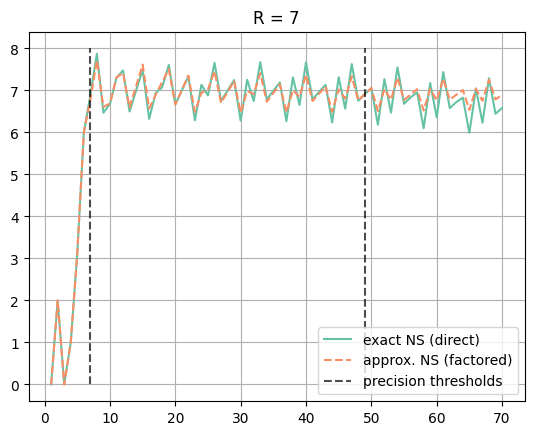

In [49]:
plt.plot(degs, res1, label='exact NS (direct)')
plt.plot(degs, res2, '--', label='approx. NS (factored)')
#plt.plot(degs, [ ck.sum() for ck in c.values() ], label='sum of counts')
plt.vlines([resolution, resolution**2], ymin=0, ymax=resolution+1, ls='--', color='black', alpha=0.7, label='precision thresholds')
plt.title(f'R = {resolution}')
plt.legend()
plt.grid()

## Dump: weird approximation of NS (abandoned trial)

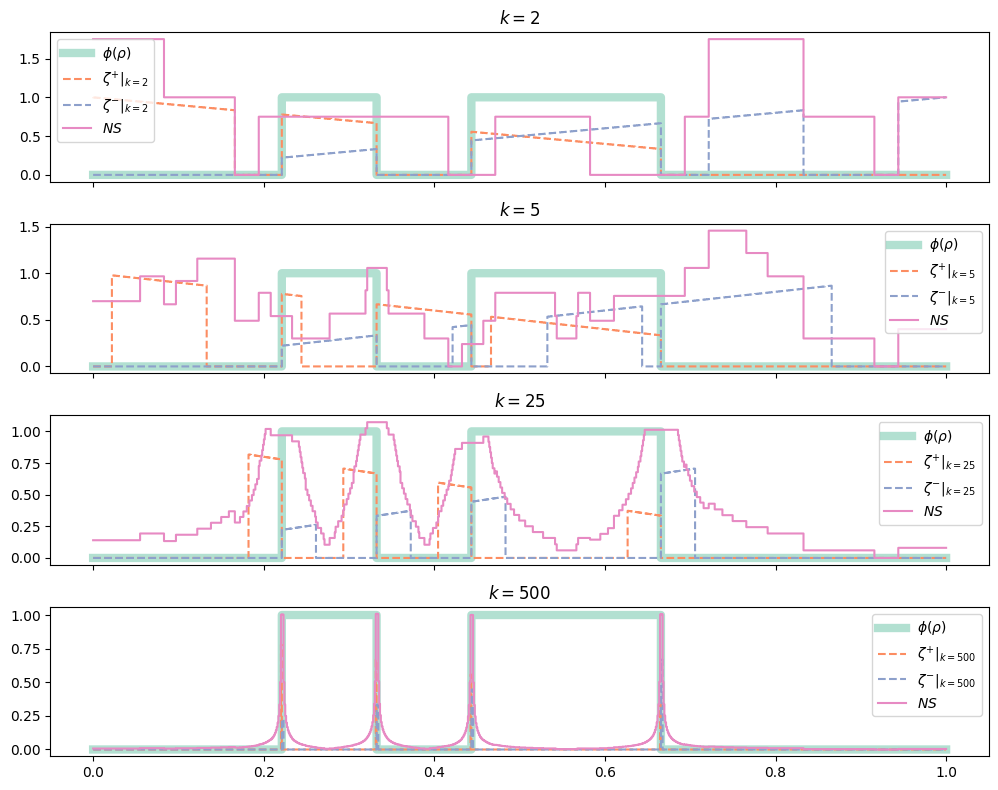

In [33]:
rho = np.linspace(0, 1, 1000)
is_in = lambda x, i, alpha: (x >= i/alpha) * (x < (i+1)/alpha)
phi = lambda x: is_in(x,2,9) + is_in(x,4,9) + is_in(x,5,9)
zeta_p = lambda x, k: (1-x) * (phi(x) ^ phi(x + 1/k))
zeta_n = lambda x, k: (x  ) * (phi(x) ^ phi(x - 1/k))
zeta_m = lambda x, k: zeta_p(x - 0.5/k, k) + zeta_n(x + 0.5/k, k)
zeta = lambda x, k_max: sum([ zeta_m(rho, k) for k in range(1, k_max+1) ]) / k_max
cprob = lambda k: np.array([ comb(k, i) for i in range (0, k+1)]) / 2**k

fig, axes = plt.subplots(4, 1, figsize=(10, 2*4), sharex=True)

for ax, k in zip(axes, [2, 5, 25, 500]):
    #ck = cprob(k)
    ax.set(title=f'$k = {k}$')
    
    ax.step(rho, phi(rho), lw=6, label='$\\phi(\\rho)$', alpha=0.5)
    ax.step(rho, zeta_p(rho, k), '--', label=f'$\\zeta^{{+}}|_{{k={k}}}$')
    ax.step(rho, zeta_n(rho, k), '--', label=f'$\\zeta^{{-}}|_{{k={k}}}$')
    #ax.step(rho, zeta_m(rho, k), label=f'$\\tilde{{\\zeta}}|_{{k={k}}}$')
    ax.step(rho, zeta(rho, k), label=f'$NS$')
    #plt.plot(rho, rho, 'k--')
    ax.legend()
plt.tight_layout()
plt.show()

In [38]:
[ zeta_m(rho, k).sum() for k in [2, 5, 100, 1000, 100000] ]

[958.5, 532.8, 36.36, 4.004, 4.00004]

In [39]:
[ zeta(rho, k).sum() for k in [2, 5, 100, 1000, 100000] ]

[813.25, 661.26, 151.24380275403158, 23.86342645001549, 4.198818451510889]